In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



image 1/1 /content/drive/MyDrive/mirasys/Crowd.jpeg: 640x448 113 peoples, 126.8ms
Speed: 2.6ms preprocess, 126.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)


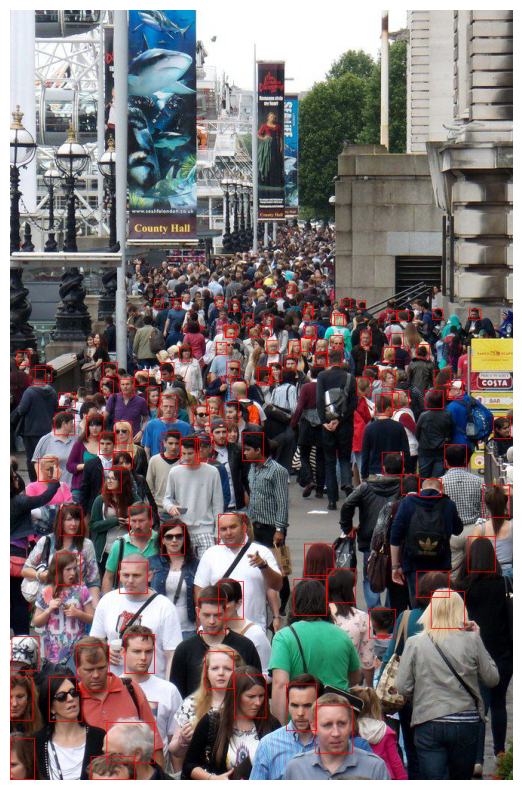

True

In [ ]:
# Install dependencies (YOLOv5/YOLOv8)
!pip install ultralytics opencv-python

# Import necessary libraries
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# Load the pre-trained model (your uploaded model)
model = YOLO("/content/drive/MyDrive/mirasys/TrainedModelCrowdDetection/best_model/detect/train/weights/best.pt")  # Make sure to upload best.pt file

# Load an image for inference (upload the image to Colab first)
image_path = "/content/drive/MyDrive/mirasys/Crowd.jpeg"  # Update with the correct image path
image = cv2.imread(image_path)

# Perform inference using the model
results = model.predict(source=image_path)

# Function to draw thin bounding boxes without confidence scores
def draw_boxes(image, results):
    for result in results:
        for box in result.boxes.xyxy:  # Extract bounding box coordinates
            x1, y1, x2, y2 = map(int, box)
            # Draw a thin blue rectangle (1px thickness)
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 1)
    return image

# Convert image to RGB for matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw the bounding boxes without confidence scores
output_image = draw_boxes(image_rgb, results)

# Display the output using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.axis("off")  # Hide axis
plt.show()

# Optionally save the output image
output_image_bgr = cv2.cvtColor(output_image, cv2.COLOR_RGB2BGR)
cv2.imwrite("/content/drive/MyDrive/mirasys/output_image2.jpg", output_image_bgr)




image 1/1 /content/drive/MyDrive/mirasys/Crowd.jpeg: 640x448 113 peoples, 193.3ms
Speed: 5.6ms preprocess, 193.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)


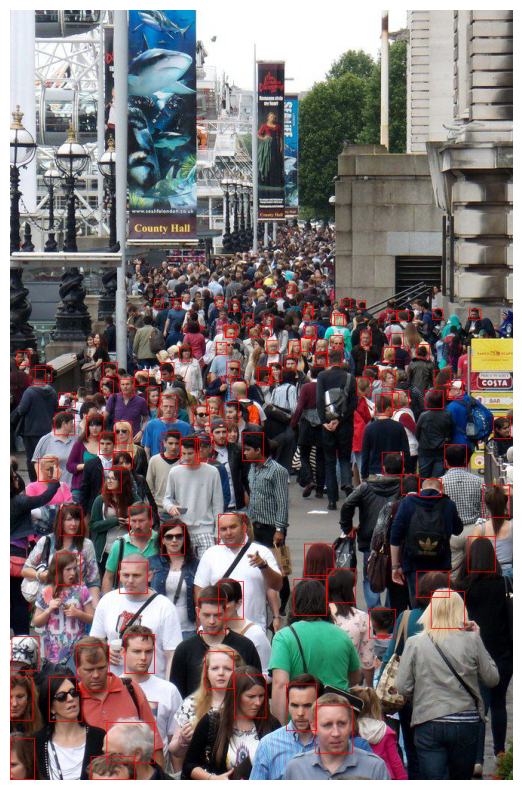

Output image saved to: /content/output_image.jpg


In [ ]:
# Perform inference using the model with lower confidence threshold (e.g., 0.25 instead of the default)
results = model.predict(source=image_path, conf=0.25)

# Process the results as before
def draw_boxes(image, results):
    for result in results:
        for box in result.boxes.xyxy:  # Extract bounding box coordinates
            x1, y1, x2, y2 = map(int, box)
            # Draw a thin blue rectangle (1px thickness)
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 1)
    return image

# Convert image to RGB for matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw the bounding boxes without confidence scores
output_image = draw_boxes(image_rgb, results)

# Display the output using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.axis("off")  # Hide axis
plt.show()

# Optionally save the output image
output_image_bgr = cv2.cvtColor(output_image, cv2.COLOR_RGB2BGR)
cv2.imwrite("/content/drive/MyDrive/mirasys/output_image2.jpg", output_image_bgr)

print("Output image saved to: /content/output_image.jpg")


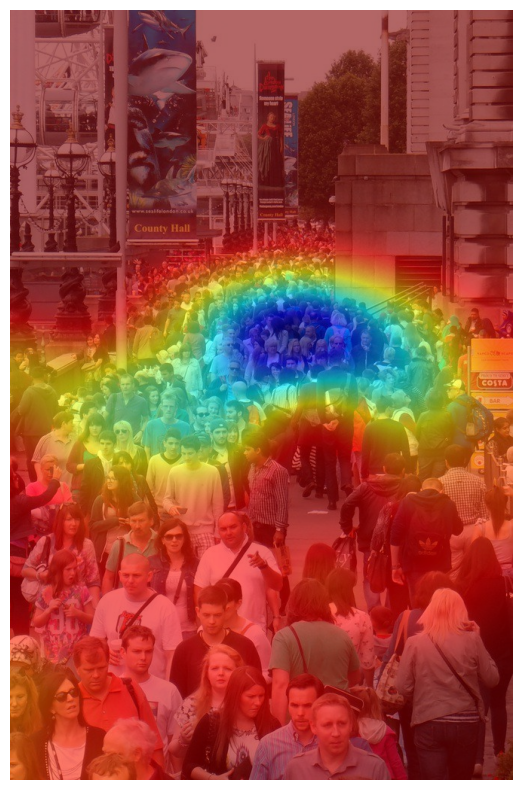

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Function to extract the centers of detected people from bounding boxes
def extract_centers(results):
    centers = []
    for result in results:
        for box in result.boxes.xyxy:  # Extract bounding box coordinates
            x1, y1, x2, y2 = map(int, box)
            # Calculate center of the bounding box
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2
            centers.append((center_x, center_y))
    return centers

# Function to generate the heatmap from detected people
def generate_heatmap(image, centers, kernel_size=50):
    heatmap = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

    # Add heat at each center point
    for (x, y) in centers:
        heatmap[y, x] += 1

    # Apply Gaussian smoothing to simulate a heatmap effect
    heatmap = gaussian_filter(heatmap, sigma=kernel_size)

    # Normalize heatmap to range between 0 and 1
    heatmap = heatmap / np.max(heatmap)

    return heatmap

# Function to overlay the heatmap on the original image
def overlay_heatmap(image, heatmap, alpha=0.6, colormap=cv2.COLORMAP_JET):
    # Convert heatmap to 8-bit (0-255) for applying colormap
    heatmap = np.uint8(255 * heatmap)

    # Apply a colormap to the heatmap
    heatmap_color = cv2.applyColorMap(heatmap, colormap)

    # Overlay the heatmap onto the original image
    overlayed_image = cv2.addWeighted(heatmap_color, alpha, image, 1 - alpha, 0)

    return overlayed_image

# Load an image for visualization (already loaded before, can reuse)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Extract the centers of detected people from results
centers = extract_centers(results)

# Generate the heatmap based on detected centers
heatmap = generate_heatmap(image_rgb, centers, kernel_size=50)

# Overlay the heatmap on the original image
output_image_with_heatmap = overlay_heatmap(image_rgb, heatmap)

# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(output_image_with_heatmap)
plt.axis("off")  # Hide the axis
plt.show()

# Optionally, save the heatmap overlay image
output_image_bgr = cv2.cvtColor(output_image_with_heatmap, cv2.COLOR_RGB2BGR)
cv2.imwrite("/content/drive/MyDrive/mirasys/output_heatmap.jpg", output_image_bgr)

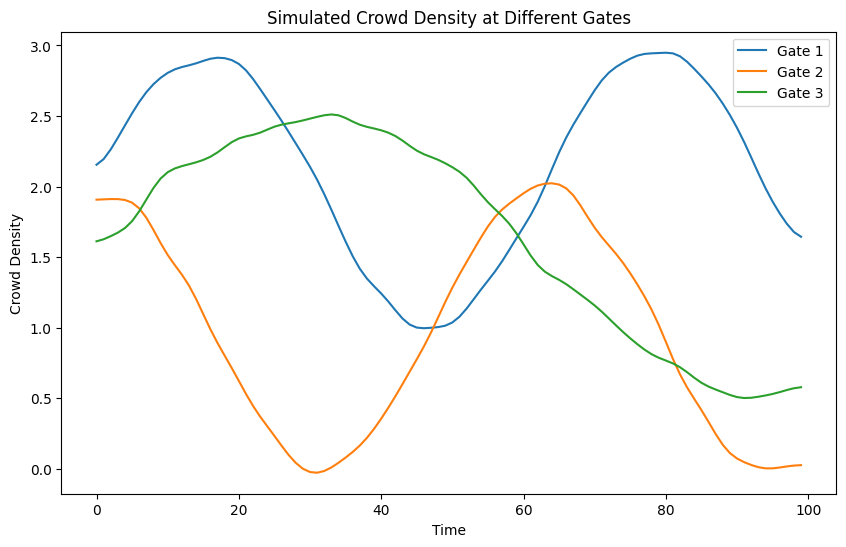

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Simulate crowd density data over time at different gates
np.random.seed(42)
time = np.arange(0, 100)  # Simulate 100 time units
gate_1_density = np.sin(time * 0.1) + np.random.normal(0, 0.1, size=time.shape) + 2  # Gate 1 density
gate_2_density = np.cos(time * 0.1) + np.random.normal(0, 0.1, size=time.shape) + 1  # Gate 2 density
gate_3_density = np.sin(time * 0.05) + np.random.normal(0, 0.1, size=time.shape) + 1.5  # Gate 3 density

# Apply Gaussian smoothing to simulate realistic crowd movement
gate_1_density = gaussian_filter(gate_1_density, sigma=2)
gate_2_density = gaussian_filter(gate_2_density, sigma=2)
gate_3_density = gaussian_filter(gate_3_density, sigma=2)

# Create a DataFrame
crowd_data = pd.DataFrame({
    'Time': time,
    'Gate 1': gate_1_density,
    'Gate 2': gate_2_density,
    'Gate 3': gate_3_density
})

# Plot the simulated crowd density
plt.figure(figsize=(10, 6))
plt.plot(time, gate_1_density, label="Gate 1")
plt.plot(time, gate_2_density, label="Gate 2")
plt.plot(time, gate_3_density, label="Gate 3")
plt.xlabel("Time")
plt.ylabel("Crowd Density")
plt.title("Simulated Crowd Density at Different Gates")
plt.legend()
plt.show()